# 成员B：数据预处理与探索性分析 (EDA)

## 项目：房屋价格分析与预测
## 数据集：Ames Housing Dataset

**成员B职责：** 完成原始房价数据的清洗、转换与探索分析，为后续建模提供高质量数据。

**工作内容：**
1. 数据质量检查（规模、字段类型、缺失值、异常值）
2. 区分结构性缺失与真实缺失，完成缺失值填补
3. 特征工程（总面积、总浴室数、房龄、建筑年代分箱）
4. 分类变量编码（有序编码 + 独热编码）
5. 目标变量对数变换与数据划分
6. 探索性数据分析（EDA）

In [1]:
# ============================================================
# 导入所需库
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import warnings
import os
warnings.filterwarnings('ignore')

# ============================================================
# 中文字体配置
# ============================================================
sns.set_style('whitegrid')
config = {
    "font.family": ["Times New Roman", "SimSun"],
    "axes.unicode_minus": False,
}
plt.rcParams.update(config)

print('字体配置完成: ' + str(plt.rcParams.get('font.family', ['default'])))

# 随机种子，保证可复现
RANDOM_STATE = 42

# 项目根目录（notebook 在 notebooks/ 子目录下）
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_RAW = os.path.join(PROJECT_ROOT, 'data', 'raw')
DATA_PROCESSED = os.path.join(PROJECT_ROOT, 'data', 'processed')
FIGURES_DIR = os.path.join(PROJECT_ROOT, 'figures')

# 创建输出目录
os.makedirs(DATA_RAW, exist_ok=True)
os.makedirs(DATA_PROCESSED, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print('库导入成功，目录已就绪。')
print(f'项目根目录: {PROJECT_ROOT}')

字体配置完成: ['Times New Roman', 'SimSun']
库导入成功，目录已就绪。
项目根目录: D:\ys\coding\DataScience\Smart-Housing-Price-Predictor


## 1. 数据加载

从 OpenML 下载 Ames Housing Dataset（公开数据集，无需认证）。首次下载后自动缓存到 `data/raw/` 目录。

In [2]:
# 从OpenML下载Ames Housing数据集（自动缓存到本地 data/raw/）
print('正在加载Ames Housing Dataset...')
ames = fetch_openml(
    name='house_prices',
    version=1,
    as_frame=True,
    data_home=DATA_RAW
)

df = ames.frame
print(f'数据集加载完成！')
print(f'  样本数: {df.shape[0]}')
print(f'  特征数（含Id和SalePrice）: {df.shape[1]}')
print(f'  数值型列: {df.select_dtypes(include=["number"]).shape[1]}')
print(f'  分类型列: {df.select_dtypes(include=["object", "category"]).shape[1]}')
print(f'  内存占用: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

# 查看前5行
df.head()

正在加载Ames Housing Dataset...
数据集加载完成！
  样本数: 1460
  特征数（含Id和SalePrice）: 81
  数值型列: 38
  分类型列: 43
  内存占用: 3.45 MB


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# 保存原始数据备份
df.to_csv(os.path.join(DATA_RAW, 'ames_raw_backup.csv'), index=False)
print(f'原始数据已备份至 {DATA_RAW}/ames_raw_backup.csv')

原始数据已备份至 D:\ys\coding\DataScience\Smart-Housing-Price-Predictor\data\raw/ames_raw_backup.csv


## 2. 数据质量检查

检查数据规模、字段类型、缺失值与异常值，区分结构性缺失与真实缺失。

In [4]:
# 字段类型分布
print('=== 字段类型分布 ===')
type_counts = df.dtypes.value_counts()
print(type_counts.to_string())
print()

# 数值型字段描述统计
print('=== 数值型字段描述统计 ===')
df.describe().round(2)

=== 字段类型分布 ===
object     43
int64      35
float64     3

=== 数值型字段描述统计 ===


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.00,1460.0,1201.00,1460.00,1460.00,1460.00,1460.00,1460.00,1452.00,1460.00,...,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.0
mean,730.50,56.9,70.05,10516.83,6.10,5.58,1971.27,1984.87,103.69,443.64,...,94.24,46.66,21.95,3.41,15.06,2.76,43.49,6.32,2007.82,180921.2
std,421.61,42.3,24.28,9981.26,1.38,1.11,30.20,20.65,181.07,456.10,...,125.34,66.26,61.12,29.32,55.76,40.18,496.12,2.70,1.33,79442.5
min,1.00,20.0,21.00,1300.00,1.00,1.00,1872.00,1950.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2006.00,34900.0
25%,365.75,20.0,59.00,7553.50,5.00,5.00,1954.00,1967.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00,2007.00,129975.0
50%,730.50,50.0,69.00,9478.50,6.00,5.00,1973.00,1994.00,0.00,383.50,...,0.00,25.00,0.00,0.00,0.00,0.00,0.00,6.00,2008.00,163000.0
75%,1095.25,70.0,80.00,11601.50,7.00,6.00,2000.00,2004.00,166.00,712.25,...,168.00,68.00,0.00,0.00,0.00,0.00,0.00,8.00,2009.00,214000.0
max,1460.00,190.0,313.00,215245.00,10.00,9.00,2010.00,2010.00,1600.00,5644.00,...,857.00,547.00,552.00,508.00,480.00,738.00,15500.00,12.00,2010.00,755000.0


In [5]:
# 分类字段概览
cat_cols = df.select_dtypes(include=['object', 'category']).columns
print(f'分类字段共 {len(cat_cols)} 个:\n')
for col in cat_cols:
    print(f'  {col:<20s}  唯一值数: {df[col].nunique()}')

分类字段共 43 个:

  MSZoning              唯一值数: 5
  Street                唯一值数: 2
  Alley                 唯一值数: 2
  LotShape              唯一值数: 4
  LandContour           唯一值数: 4
  Utilities             唯一值数: 2
  LotConfig             唯一值数: 5
  LandSlope             唯一值数: 3
  Neighborhood          唯一值数: 25
  Condition1            唯一值数: 9
  Condition2            唯一值数: 8
  BldgType              唯一值数: 5
  HouseStyle            唯一值数: 8
  RoofStyle             唯一值数: 6
  RoofMatl              唯一值数: 8
  Exterior1st           唯一值数: 15
  Exterior2nd           唯一值数: 16
  MasVnrType            唯一值数: 4
  ExterQual             唯一值数: 4
  ExterCond             唯一值数: 5
  Foundation            唯一值数: 6
  BsmtQual              唯一值数: 4
  BsmtCond              唯一值数: 4
  BsmtExposure          唯一值数: 4
  BsmtFinType1          唯一值数: 6
  BsmtFinType2          唯一值数: 6
  Heating               唯一值数: 6
  HeatingQC             唯一值数: 5
  CentralAir            唯一值数: 2
  Electrical            唯一值数: 5
  KitchenQual           

In [6]:
# 缺失值分析
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    '缺失数量': missing,
    '缺失比例(%)': missing_pct
})
print(f'存在缺失值的字段共 {len(missing_df)} 个:')
missing_df

存在缺失值的字段共 19 个:


,缺失数量,缺失比例(%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageCond,81,5.55
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


In [7]:
# 区分结构性缺失 vs 真实缺失
# 结构性缺失：NA 表示该设施不存在（非数据缺失）
structural_na_info = {
    'PoolQC':        '无游泳池 (99.5%)',
    'MiscFeature':   '无其他特征 (96.3%)',
    'Alley':         '无巷子通道 (93.8%)',
    'Fence':         '无围栏 (80.8%)',
    'FireplaceQu':   '无壁炉 (47.3%)',
    'GarageType':    '无车库 (5.5%)',
    'GarageYrBlt':   '无车库 (5.5%)',
    'GarageFinish':  '无车库 (5.5%)',
    'GarageQual':    '无车库 (5.5%)',
    'GarageCond':    '无车库 (5.5%)',
    'BsmtQual':      '无地下室 (~2.5%)',
    'BsmtCond':      '无地下室 (~2.5%)',
    'BsmtExposure':  '无地下室 (~2.5%)',
    'BsmtFinType1':  '无地下室 (~2.5%)',
    'BsmtFinType2':  '无地下室 (~2.5%)',
}

# 真实缺失（需要填补）
real_missing_info = {
    'LotFrontage':   '街道临街长度 — 259个缺失 (17.7%)',
    'MasVnrType':    '砌体饰面类型 — 8个缺失 (0.5%)',
    'MasVnrArea':    '砌体饰面面积 — 8个缺失 (0.5%)',
    'Electrical':    '电气系统 — 1个缺失 (0.07%)',
}

print('=== 结构性缺失（NA = 设施不存在，填充为 "None" 或 0）===')
for col, desc in structural_na_info.items():
    na_count = df[col].isnull().sum()
    if na_count > 0:
        print(f'  {col:<15s}  {na_count:>4d} 个缺失  — {desc}')

print(f'\n=== 真实缺失（需填补）===')
for col, desc in real_missing_info.items():
    na_count = df[col].isnull().sum()
    print(f'  {col:<15s}  {na_count:>4d} 个缺失  — {desc}')

=== 结构性缺失（NA = 设施不存在，填充为 "None" 或 0）===
  PoolQC           1453 个缺失  — 无游泳池 (99.5%)
  MiscFeature      1406 个缺失  — 无其他特征 (96.3%)
  Alley            1369 个缺失  — 无巷子通道 (93.8%)
  Fence            1179 个缺失  — 无围栏 (80.8%)
  FireplaceQu       690 个缺失  — 无壁炉 (47.3%)
  GarageType         81 个缺失  — 无车库 (5.5%)
  GarageYrBlt        81 个缺失  — 无车库 (5.5%)
  GarageFinish       81 个缺失  — 无车库 (5.5%)
  GarageQual         81 个缺失  — 无车库 (5.5%)
  GarageCond         81 个缺失  — 无车库 (5.5%)
  BsmtQual           37 个缺失  — 无地下室 (~2.5%)
  BsmtCond           37 个缺失  — 无地下室 (~2.5%)
  BsmtExposure       38 个缺失  — 无地下室 (~2.5%)
  BsmtFinType1       37 个缺失  — 无地下室 (~2.5%)
  BsmtFinType2       38 个缺失  — 无地下室 (~2.5%)

=== 真实缺失（需填补）===
  LotFrontage       259 个缺失  — 街道临街长度 — 259个缺失 (17.7%)
  MasVnrType          8 个缺失  — 砌体饰面类型 — 8个缺失 (0.5%)
  MasVnrArea          8 个缺失  — 砌体饰面面积 — 8个缺失 (0.5%)
  Electrical          1 个缺失  — 电气系统 — 1个缺失 (0.07%)


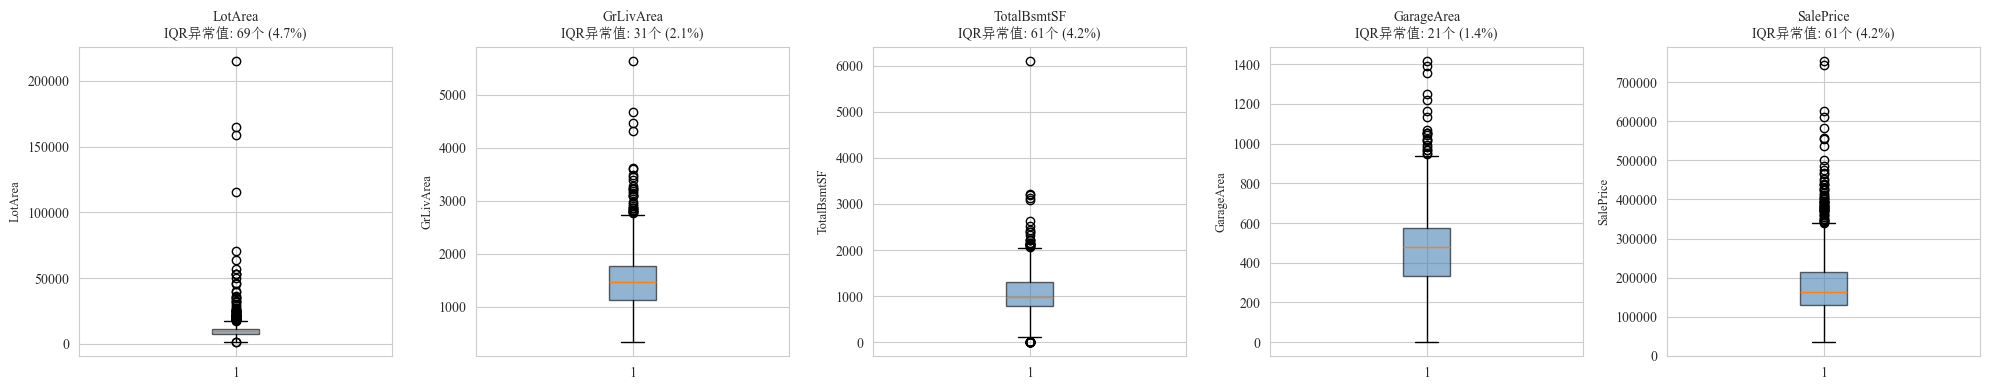

异常值检测图已保存至 D:\ys\coding\DataScience\Smart-Housing-Price-Predictor\figures/outlier_detection.png


In [8]:
# 异常值检测 — 关键数值字段的箱线图
key_num_cols = ['LotArea', 'GrLivArea', 'TotalBsmtSF', 'GarageArea', 'SalePrice']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(key_num_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{col}\nIQR异常值: {n_outliers}个 ({n_outliers/len(df)*100:.1f}%)', fontsize=10)
    axes[i].set_ylabel(col, fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'outlier_detection.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'异常值检测图已保存至 {FIGURES_DIR}/outlier_detection.png')

## 3. 缺失值处理

- **结构性缺失**：分类字段填充 `"None"`，数值字段填充 `0`
- **真实缺失**：按业务逻辑填补（街区中位数、众数等）

In [9]:
# ============================================================
# 3.1 处理结构性缺失 — 分类字段：填充 "None"
# ============================================================

# 无此设施类
df['Alley'] = df['Alley'].fillna('None')
df['PoolQC'] = df['PoolQC'].fillna('None')
df['Fence'] = df['Fence'].fillna('None')
df['MiscFeature'] = df['MiscFeature'].fillna('None')
df['FireplaceQu'] = df['FireplaceQu'].fillna('None')

# 无地下室类
for col in ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']:
    df[col] = df[col].fillna('None')

# 无车库类
df['GarageType'] = df['GarageType'].fillna('None')
df['GarageFinish'] = df['GarageFinish'].fillna('None')
df['GarageQual'] = df['GarageQual'].fillna('None')
df['GarageCond'] = df['GarageCond'].fillna('None')

print('结构性缺失（分类字段）已处理完成。')

# 3.2 结构性缺失 — 数值字段
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

print('结构性缺失（数值字段）已处理完成。')

结构性缺失（分类字段）已处理完成。
结构性缺失（数值字段）已处理完成。


In [10]:
# ============================================================
# 3.3 处理真实缺失
# ============================================================

# LotFrontage: 按街区中位数填补（同一街区房屋临街长度相近）
lot_frontage_median = df.groupby('Neighborhood')['LotFrontage'].transform('median')
df['LotFrontage'] = df['LotFrontage'].fillna(lot_frontage_median)
# 若某街区全部为NA，回退到全局中位数
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

# MasVnrType: 众数填补
df['MasVnrType'] = df['MasVnrType'].fillna(df['MasVnrType'].mode()[0])

# MasVnrArea: 中位数填补（对于无饰面的房屋填0更合理，但此处按统计填补）
df['MasVnrArea'] = df['MasVnrArea'].fillna(df['MasVnrArea'].median())

# Electrical: 众数填补（仅1个缺失）
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# 验证
remaining_na = df.isnull().sum().sum()
print(f'缺失值处理完成！剩余缺失值总数: {remaining_na}')
assert remaining_na == 0, f'仍有 {remaining_na} 个缺失值未处理！'

缺失值处理完成！剩余缺失值总数: 0


## 4. 特征工程

创建以下新特征：
- **TotalArea** — 房屋总面积
- **TotalBathrooms** — 总浴室数
- **HouseAge** — 房龄
- **RemodAge** — 装修龄
- **AgeBand** — 建筑年代分箱

In [11]:
# ============================================================
# 4.1 房屋总面积
# 对房屋各部分面积求和（使用非冗余列避免重复计数）
# GrLivArea = 1stFlrSF + 2ndFlrSF + LowQualFinSF（已包含子部分）
# TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF（已包含子部分）
# 故只用顶层列，不用子部分列
# ============================================================
area_columns = [
    'LotArea',        # 地块面积
    'TotalBsmtSF',    # 地下室总面积
    '1stFlrSF',       # 一层面积
    '2ndFlrSF',       # 二层面积
    'LowQualFinSF',   # 低质量完工面积
    'GarageArea',     # 车库面积
    'WoodDeckSF',     # 木制平台面积
    'OpenPorchSF',    # 开放式门廊面积
    'EnclosedPorch',  # 封闭式门廊面积
    '3SsnPorch',      # 三季门廊面积
    'ScreenPorch',    # 纱窗门廊面积
    'PoolArea',       # 游泳池面积
    'MasVnrArea',     # 砌体饰面面积
]
df['TotalArea'] = df[area_columns].sum(axis=1)

print(f'房屋总面积 (TotalArea) 统计:')
print(df['TotalArea'].describe().round(1))
print(f'\n面积列名称: {area_columns}')

房屋总面积 (TotalArea) 统计:
count      1460.0
mean      13849.9
std       10379.6
min        2793.0
25%       10309.2
50%       12631.0
75%       15542.2
max      219930.0
Name: TotalArea, dtype: float64

面积列名称: ['LotArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MasVnrArea']


In [12]:
# ============================================================
# 4.2 总浴室数 (半浴室计0.5)
# ============================================================
df['TotalBathrooms'] = (
    df['FullBath'] +
    df['HalfBath'] * 0.5 +
    df['BsmtFullBath'] +
    df['BsmtHalfBath'] * 0.5
)

print('总浴室数 (TotalBathrooms) 分布:')
print(df['TotalBathrooms'].value_counts().sort_index())

总浴室数 (TotalBathrooms) 分布:
TotalBathrooms
1.0    228
1.5    129
2.0    456
2.5    295
3.0    186
3.5    144
4.0     13
4.5      7
5.0      1
6.0      1
Name: count, dtype: int64


In [13]:
# ============================================================
# 4.3 房龄与装修龄
# ============================================================
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

print(f'房龄 (HouseAge) — 均值: {df["HouseAge"].mean():.1f}年, '
      f'范围: {df["HouseAge"].min()}~{df["HouseAge"].max()}年')
print(f'装修龄 (RemodAge) — 均值: {df["RemodAge"].mean():.1f}年, '
      f'范围: {df["RemodAge"].min()}~{df["RemodAge"].max()}年')

# 翻新过的房屋比例
renovated = (df['YearRemodAdd'] != df['YearBuilt']).sum()
print(f'\n进行过翻新的房屋: {renovated} 套 ({renovated/len(df)*100:.1f}%)')

房龄 (HouseAge) — 均值: 36.5年, 范围: 0~136年
装修龄 (RemodAge) — 均值: 22.9年, 范围: -1~60年

进行过翻新的房屋: 696 套 (47.7%)


In [14]:
# ============================================================
# 4.4 建筑年代分箱
# ============================================================
age_bins = [0, 10, 20, 30, 50, 100, 200]
age_labels = ['<10年', '10-20年', '20-30年', '30-50年', '50-100年', '>100年']

df['AgeBand'] = pd.cut(df['HouseAge'], bins=age_bins, labels=age_labels)

print('房屋年龄分段统计:')
age_dist = df['AgeBand'].value_counts().sort_index()
for label, count in age_dist.items():
    bar = '█' * (count // 20)
    print(f'  {label:<10s}  {count:>4d} 套  {bar}')

房屋年龄分段统计:
  <10年         370 套  ██████████████████
  10-20年       130 套  ██████
  20-30年        78 套  ███
  30-50年       379 套  ██████████████████
  50-100年      411 套  ████████████████████
  >100年         28 套  █


## 5. 分类变量编码

- **有序编码**：19个有序分类变量，按等级映射为整数
- **二值编码**：2个二分类变量映射为 0/1
- **独热编码**：22个名义分类变量展开为 dummy 列

In [15]:
# ============================================================
# 5.1 有序编码 (Ordinal Encoding)
# ============================================================
ordinal_mappings = {
    # 质量等级: None(设施不存在)=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5
    'ExterQual':    {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'ExterCond':    {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtQual':     {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtCond':     {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'HeatingQC':    {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'KitchenQual':  {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'FireplaceQu':  {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageQual':   {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageCond':   {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'PoolQC':       {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},

    # 地块形状: 越规则越好
    'LotShape':     {'IR3': 0, 'IR2': 1, 'IR1': 2, 'Reg': 3},
    'LandSlope':    {'Sev': 0, 'Mod': 1, 'Gtl': 2},

    # 地下室相关
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFinType2': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},

    # 车库
    'GarageFinish': {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},

    # 车道
    'PavedDrive':   {'N': 0, 'P': 1, 'Y': 2},

    # 功能等级
    'Functional':   {'Sev': 0, 'Maj2': 1, 'Mod': 2, 'Maj1': 3,
                     'Min2': 4, 'Min1': 5, 'Typ': 6},

    # 公用设施 (绝大部分为 AllPub)
    'Utilities':    {'NoSeWa': 0, 'AllPub': 1},
}

for col, mapping in ordinal_mappings.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)
    else:
        print(f'  警告: {col} 不在数据集中')

print(f'有序编码完成！共 {len(ordinal_mappings)} 个字段。')

有序编码完成！共 19 个字段。


In [16]:
# ============================================================
# 5.2 二值编码
# ============================================================
binary_mappings = {
    'Street':      {'Grvl': 0, 'Pave': 1},
    'CentralAir':  {'N': 0, 'Y': 1},
}
for col, mapping in binary_mappings.items():
    df[col] = df[col].map(mapping)

print('二值编码完成：Street, CentralAir')

二值编码完成：Street, CentralAir


In [17]:
# ============================================================
# 5.3 独热编码 (名义分类变量，无序)
# ============================================================
nominal_cols = [
    'MSZoning', 'LandContour', 'LotConfig', 'Neighborhood',
    'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
    'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
    'Foundation', 'Heating', 'Electrical', 'GarageType',
    'MasVnrType', 'Fence', 'MiscFeature', 'SaleType',
    'SaleCondition', 'Alley',
]

# 过滤实际存在的列
nominal_cols = [c for c in nominal_cols if c in df.columns]

df_before = df.shape[1]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=False)
df_after = df.shape[1]

print(f'独热编码完成！')
print(f'  编码前列数: {df_before}')
print(f'  编码后列数: {df_after}')
print(f'  新增 dummy 列: {df_after - df_before}')
print(f'  名义编码字段: {nominal_cols}')

独热编码完成！
  编码前列数: 86
  编码后列数: 234
  新增 dummy 列: 148
  名义编码字段: ['MSZoning', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'Foundation', 'Heating', 'Electrical', 'GarageType', 'MasVnrType', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition', 'Alley']


## 6. 目标变量处理与数据划分

- 对 `SalePrice` 进行对数变换，使分布接近正态
- 按 80%/20% 划分训练集与测试集
- 导出处理后的数据供成员C使用

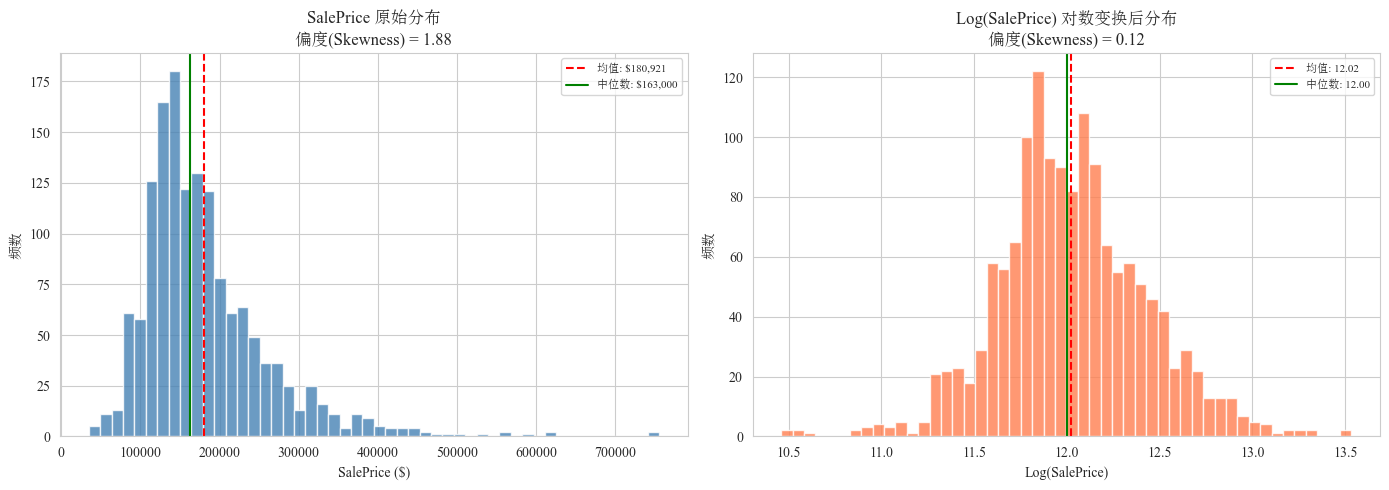

原始 SalePrice  偏度: 1.883
Log(SalePrice)   偏度: 0.121
对数变换使分布接近正态，有利于线性模型。


In [18]:
# ============================================================
# 6.1 SalePrice 对数变换
# ============================================================
df['LogSalePrice'] = np.log(df['SalePrice'])

# 对比变换前后的分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--',
                label=f'均值: ${df["SalePrice"].mean():,.0f}')
axes[0].axvline(df['SalePrice'].median(), color='green', linestyle='-',
                label=f'中位数: ${df["SalePrice"].median():,.0f}')
axes[0].set_title(f'SalePrice 原始分布\n偏度(Skewness) = {df["SalePrice"].skew():.2f}')
axes[0].set_xlabel('SalePrice ($)')
axes[0].set_ylabel('频数')
axes[0].legend(fontsize=8)

axes[1].hist(df['LogSalePrice'], bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(df['LogSalePrice'].mean(), color='red', linestyle='--',
                label=f'均值: {df["LogSalePrice"].mean():.2f}')
axes[1].axvline(df['LogSalePrice'].median(), color='green', linestyle='-',
                label=f'中位数: {df["LogSalePrice"].median():.2f}')
axes[1].set_title(f'Log(SalePrice) 对数变换后分布\n偏度(Skewness) = {df["LogSalePrice"].skew():.2f}')
axes[1].set_xlabel('Log(SalePrice)')
axes[1].set_ylabel('频数')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sale_price_log_transform.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'原始 SalePrice  偏度: {df["SalePrice"].skew():.3f}')
print(f'Log(SalePrice)   偏度: {df["LogSalePrice"].skew():.3f}')
print(f'对数变换使分布接近正态，有利于线性模型。')

In [19]:
# ============================================================
# 6.2 准备特征矩阵与目标变量
# ============================================================

# 保存Id列
ids = df['Id'].copy()

# 目标变量
y = df[['Id', 'SalePrice', 'LogSalePrice']].copy()

# 特征矩阵：去掉Id、目标变量、时间列、原始面积子列、AgeBand（已编码到dummy或保留为cat）
drop_cols = ['Id', 'SalePrice', 'LogSalePrice']

# 去掉时间相关列（已用于特征工程，避免数据泄露）
time_cols = ['YearBuilt', 'YearRemodAdd', 'YrSold', 'MoSold', 'GarageYrBlt']
drop_cols.extend([c for c in time_cols if c in df.columns])

# 去掉原始面积列（已汇总到 TotalArea）
area_drop = ['LotArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
             'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
             '3SsnPorch', 'ScreenPorch', 'PoolArea', 'LowQualFinSF', 'MasVnrArea']
drop_cols.extend([c for c in area_drop if c in df.columns])

# 去掉 AgeBand 分类列（保留编码后的dummy）
if 'AgeBand' in df.columns:
    drop_cols.append('AgeBand')

# 去重
drop_cols = list(set(drop_cols) & set(df.columns))

X = df.drop(columns=drop_cols)

print(f'特征矩阵 X 形状: {X.shape}')
print(f'目标变量 y 形状: {y.shape}')
print(f'去掉的列: {drop_cols}')

特征矩阵 X 形状: (1460, 213)
目标变量 y 形状: (1460, 3)
去掉的列: ['SalePrice', 'OpenPorchSF', 'PoolArea', 'YearBuilt', 'GarageArea', 'Id', '2ndFlrSF', 'MasVnrArea', 'LowQualFinSF', 'YearRemodAdd', 'LogSalePrice', 'TotalBsmtSF', '3SsnPorch', '1stFlrSF', 'YrSold', 'WoodDeckSF', 'AgeBand', 'ScreenPorch', 'EnclosedPorch', 'MoSold', 'GarageYrBlt', 'LotArea']


In [20]:
# ============================================================
# 6.3 80% / 20% 训练测试集划分
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print('数据划分结果:')
print(f'  训练集: X_train {X_train.shape}, y_train {y_train.shape}')
print(f'  测试集: X_test  {X_test.shape},  y_test  {y_test.shape}')
print(f'  训练集占比: {len(X_train)/len(X)*100:.1f}%')
print(f'  测试集占比: {len(X_test)/len(X)*100:.1f}%')

数据划分结果:
  训练集: X_train (1168, 213), y_train (1168, 3)
  测试集: X_test  (292, 213),  y_test  (292, 3)
  训练集占比: 80.0%
  测试集占比: 20.0%


In [21]:
# ============================================================
# 6.4 导出处理后的数据供成员C使用
# ============================================================
X_train.to_csv(os.path.join(DATA_PROCESSED, 'X_train.csv'), index=False)
X_test.to_csv(os.path.join(DATA_PROCESSED, 'X_test.csv'), index=False)
y_train.to_csv(os.path.join(DATA_PROCESSED, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(DATA_PROCESSED, 'y_test.csv'), index=False)

# 同时导出特征列名列表，方便成员C了解数据结构
feature_cols_path = os.path.join(DATA_PROCESSED, 'feature_columns.txt')
with open(feature_cols_path, 'w', encoding='utf-8') as f:
    f.write('训练/测试集特征列名（共{}列）:\n'.format(X_train.shape[1]))
    for i, col in enumerate(X_train.columns, 1):
        f.write(f'  {i:>3d}. {col}\n')

print(f'处理后的数据已导出至 {DATA_PROCESSED}/ 目录：')
print(f'  X_train.csv  — 训练集特征 ({X_train.shape[0]}行 × {X_train.shape[1]}列)')
print(f'  X_test.csv   — 测试集特征 ({X_test.shape[0]}行 × {X_test.shape[1]}列)')
print(f'  y_train.csv  — 训练集目标 (含 SalePrice 和 LogSalePrice)')
print(f'  y_test.csv   — 测试集目标 (含 SalePrice 和 LogSalePrice)')
print(f'  feature_columns.txt — 特征列名列表')

处理后的数据已导出至 D:\ys\coding\DataScience\Smart-Housing-Price-Predictor\data\processed/ 目录：
  X_train.csv  — 训练集特征 (1168行 × 213列)
  X_test.csv   — 测试集特征 (292行 × 213列)
  y_train.csv  — 训练集目标 (含 SalePrice 和 LogSalePrice)
  y_test.csv   — 测试集目标 (含 SalePrice 和 LogSalePrice)
  feature_columns.txt — 特征列名列表


## 7. 探索性数据分析 (EDA)

从以下五个维度分析数据特征：
1. 房价分布
2. 面积与价格关系
3. 街区价格差异
4. 时间维度价格变化
5. 特征相关性热力图

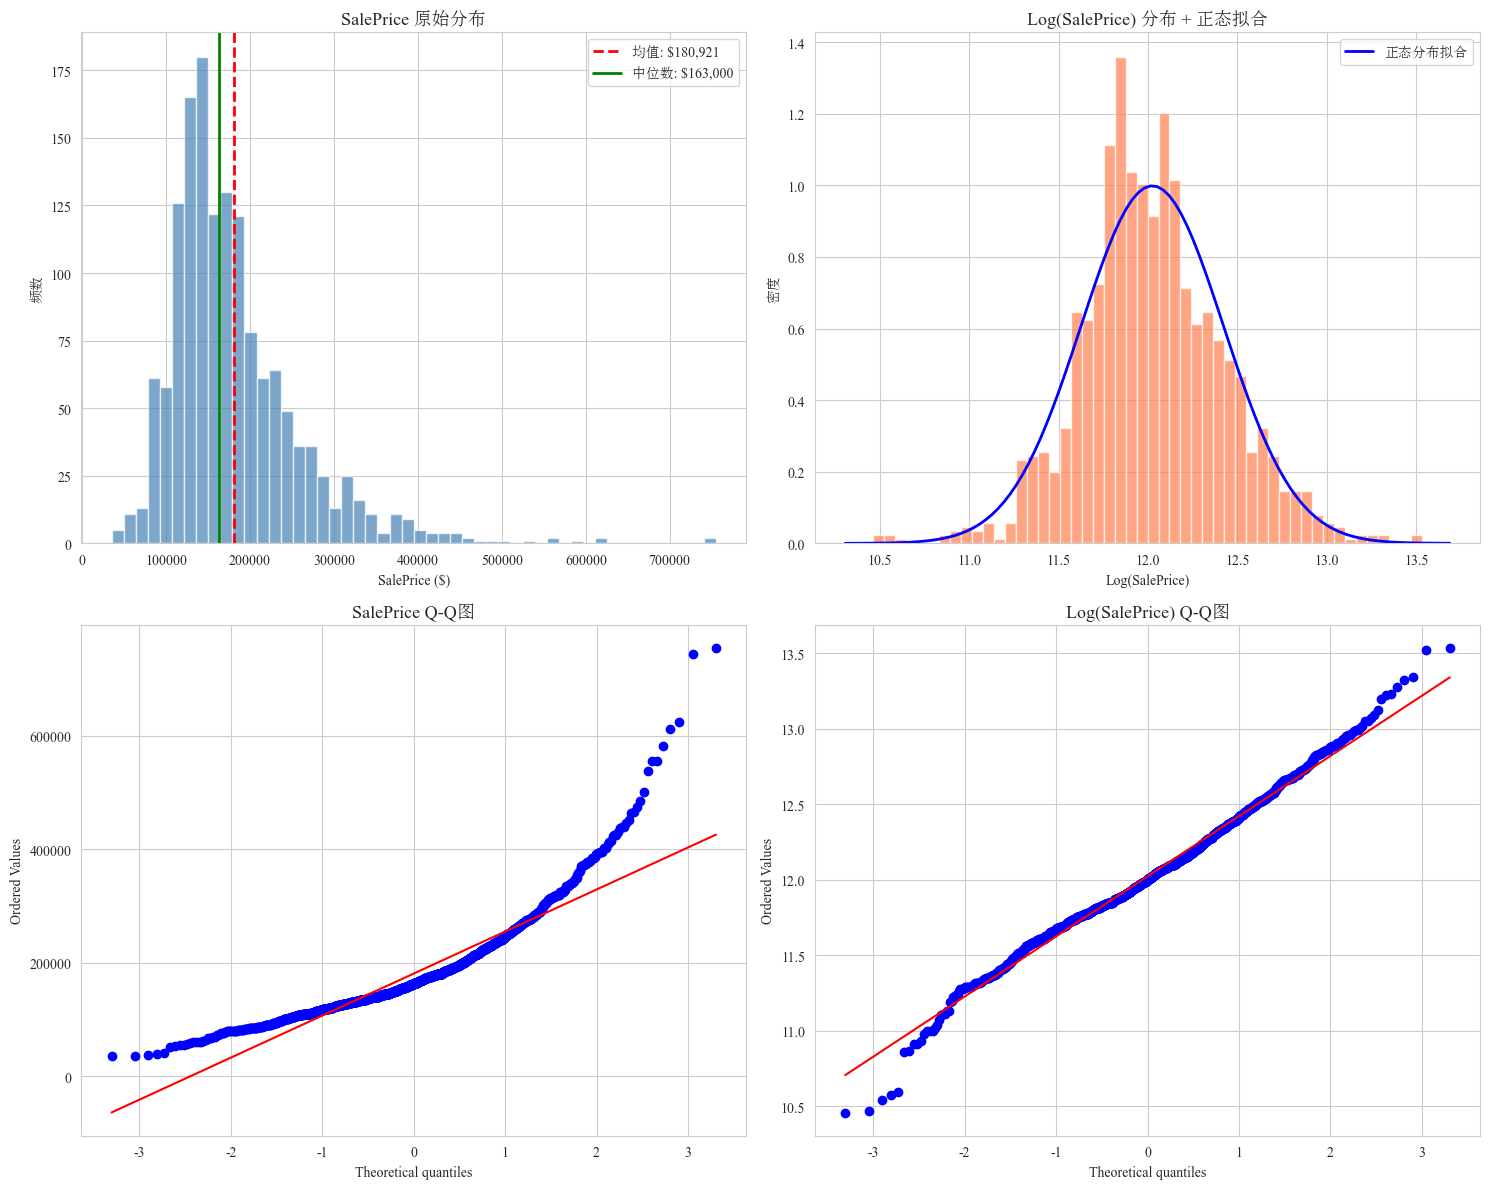

=== 房价分布关键指标 ===
  均值:        $180,921
  中位数:      $163,000
  标准差:      $79,443
  最小值:      $34,900
  最大值:      $755,000
  偏度:        1.883
  对数后偏度:  0.121


In [22]:
# ============================================================
# 7.1 房价分布分析
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 原始分布直方图
axes[0, 0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0, 0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f'均值: ${df["SalePrice"].mean():,.0f}')
axes[0, 0].axvline(df['SalePrice'].median(), color='green', linestyle='-', linewidth=2,
                   label=f'中位数: ${df["SalePrice"].median():,.0f}')
axes[0, 0].set_title('SalePrice 原始分布', fontsize=13)
axes[0, 0].set_xlabel('SalePrice ($)')
axes[0, 0].set_ylabel('频数')
axes[0, 0].legend()

# 对数分布直方图 + KDE
axes[0, 1].hist(df['LogSalePrice'], bins=50, color='coral', edgecolor='white',
                alpha=0.7, density=True)
from scipy.stats import norm
xmin, xmax = axes[0, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
mu, std = df['LogSalePrice'].mean(), df['LogSalePrice'].std()
axes[0, 1].plot(x, norm.pdf(x, mu, std), 'b-', linewidth=2, label='正态分布拟合')
axes[0, 1].set_title('Log(SalePrice) 分布 + 正态拟合', fontsize=13)
axes[0, 1].set_xlabel('Log(SalePrice)')
axes[0, 1].set_ylabel('密度')
axes[0, 1].legend()

# Q-Q图
stats.probplot(df['SalePrice'], dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('SalePrice Q-Q图', fontsize=13)
stats.probplot(df['LogSalePrice'], dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Log(SalePrice) Q-Q图', fontsize=13)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sale_price_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'=== 房价分布关键指标 ===')
print(f'  均值:        ${df["SalePrice"].mean():,.0f}')
print(f'  中位数:      ${df["SalePrice"].median():,.0f}')
print(f'  标准差:      ${df["SalePrice"].std():,.0f}')
print(f'  最小值:      ${df["SalePrice"].min():,.0f}')
print(f'  最大值:      ${df["SalePrice"].max():,.0f}')
print(f'  偏度:        {df["SalePrice"].skew():.3f}')
print(f'  对数后偏度:  {df["LogSalePrice"].skew():.3f}')

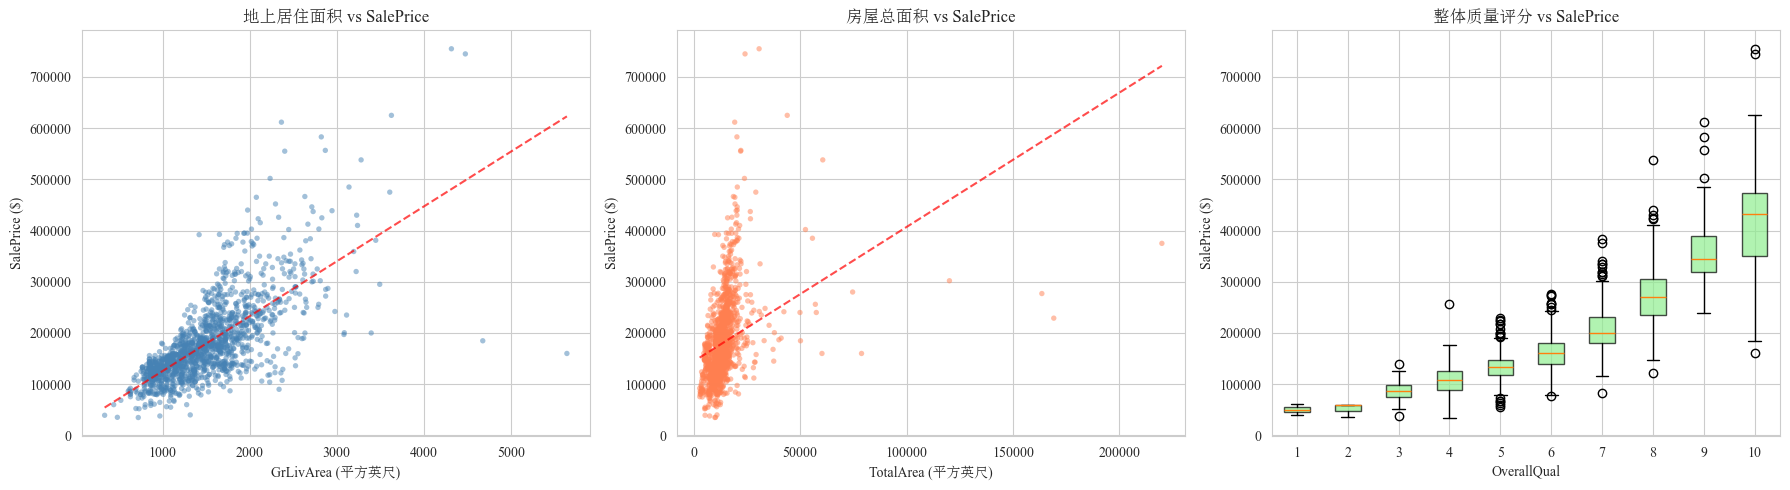

GrLivArea 与 SalePrice 相关系数: 0.709
TotalArea 与 SalePrice 相关系数: 0.343
OverallQual 与 SalePrice 相关系数: 0.791


In [23]:
# ============================================================
# 7.2 面积与价格关系
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# GrLivArea vs SalePrice
axes[0].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5, s=15,
                c='steelblue', edgecolors='none')
z = np.polyfit(df['GrLivArea'], df['SalePrice'], 1)
p = np.poly1d(z)
axes[0].plot(sorted(df['GrLivArea']), p(sorted(df['GrLivArea'])),
             'r--', linewidth=1.5, alpha=0.7)
axes[0].set_title('地上居住面积 vs SalePrice', fontsize=12)
axes[0].set_xlabel('GrLivArea (平方英尺)')
axes[0].set_ylabel('SalePrice ($)')

# TotalArea vs SalePrice
axes[1].scatter(df['TotalArea'], df['SalePrice'], alpha=0.5, s=15,
                c='coral', edgecolors='none')
z = np.polyfit(df['TotalArea'], df['SalePrice'], 1)
p = np.poly1d(z)
axes[1].plot(sorted(df['TotalArea']), p(sorted(df['TotalArea'])),
             'r--', linewidth=1.5, alpha=0.7)
axes[1].set_title('房屋总面积 vs SalePrice', fontsize=12)
axes[1].set_xlabel('TotalArea (平方英尺)')
axes[1].set_ylabel('SalePrice ($)')

# OverallQual vs SalePrice
overall_qual_data = [df[df['OverallQual'] == q]['SalePrice']
                     for q in sorted(df['OverallQual'].unique())]
bp = axes[2].boxplot(overall_qual_data, patch_artist=True,
                     labels=sorted(df['OverallQual'].unique()))
for patch in bp['boxes']:
    patch.set_facecolor('lightgreen')
    patch.set_alpha(0.7)
axes[2].set_title('整体质量评分 vs SalePrice', fontsize=12)
axes[2].set_xlabel('OverallQual')
axes[2].set_ylabel('SalePrice ($)')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'area_vs_price.png'), dpi=150, bbox_inches='tight')
plt.show()

# 相关系数
print(f'GrLivArea 与 SalePrice 相关系数: {df["GrLivArea"].corr(df["SalePrice"]):.3f}')
print(f'TotalArea 与 SalePrice 相关系数: {df["TotalArea"].corr(df["SalePrice"]):.3f}')
print(f'OverallQual 与 SalePrice 相关系数: {df["OverallQual"].corr(df["SalePrice"]):.3f}')

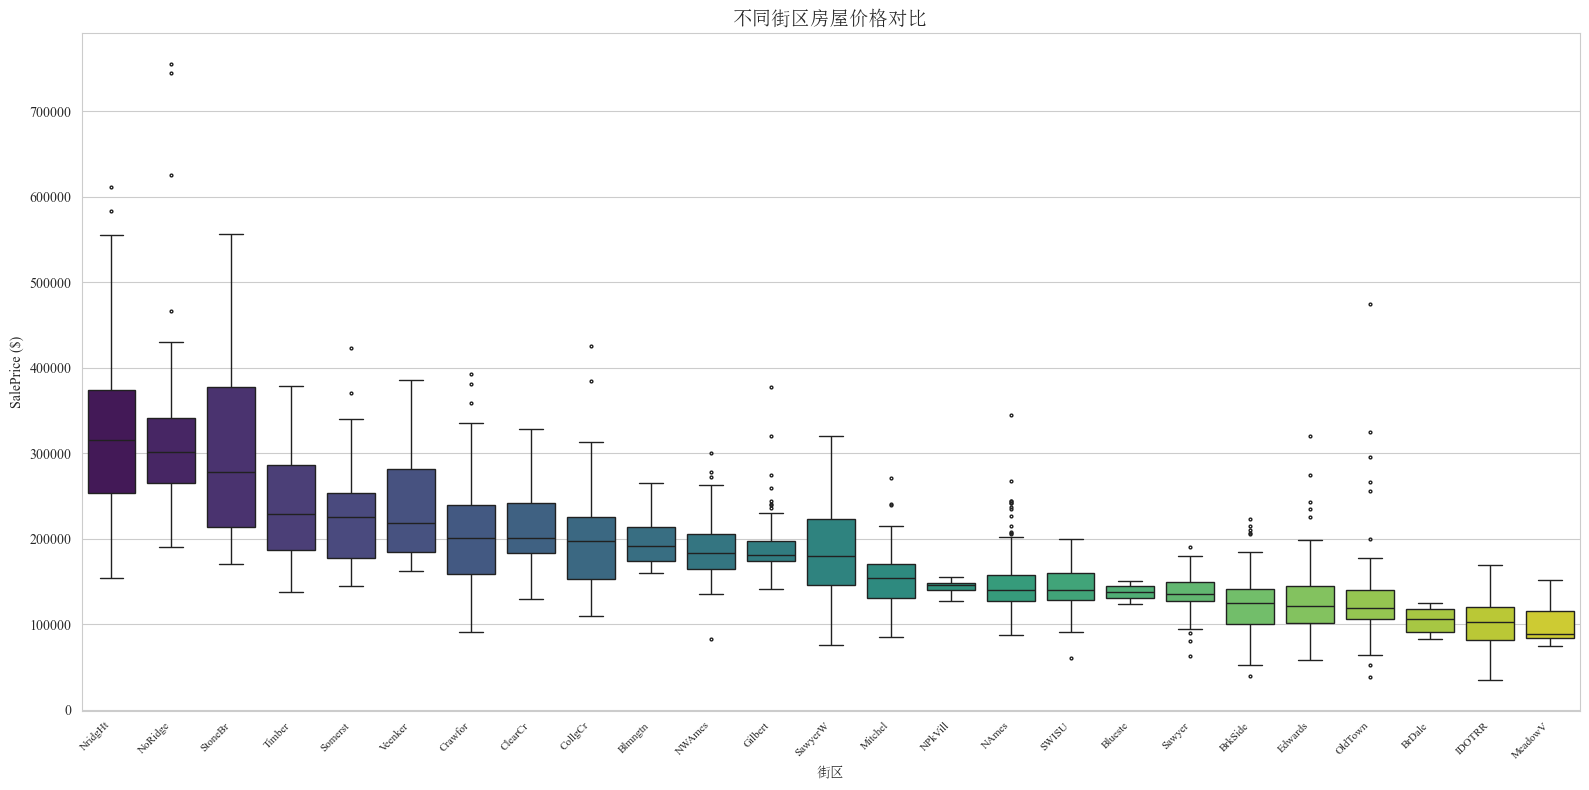

各街区房价统计（按中位数降序，前10）:


,房屋数量,均值($),中位数($),标准差($)
Neighborhood,,,,
NridgHt,77,316271.0,315000.0,96393.0
NoRidge,41,335295.0,301500.0,121413.0
StoneBr,25,310499.0,278000.0,112970.0
Timber,38,242247.0,228475.0,64846.0
Somerst,86,225380.0,225500.0,56178.0
Veenker,11,238773.0,218000.0,72369.0
Crawfor,51,210625.0,200624.0,68866.0
ClearCr,28,212565.0,200250.0,50232.0
CollgCr,150,197966.0,197200.0,51404.0


In [24]:
# ============================================================
# 7.3 街区价格差异
# 注：独热编码后Neighborhood已被拆分，此分析回退到原始数据
# ============================================================
# 重新加载原始数据用于EDA可视化
raw = fetch_openml(name='house_prices', version=1, as_frame=True,
                   data_home=DATA_RAW).frame

plt.figure(figsize=(16, 8))
order = raw.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index

sns.boxplot(data=raw, x='Neighborhood', y='SalePrice', order=order,
            palette='viridis', fliersize=2)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('不同街区房屋价格对比', fontsize=14)
plt.xlabel('街区')
plt.ylabel('SalePrice ($)')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'neighborhood_price.png'), dpi=150, bbox_inches='tight')
plt.show()

# 统计表
neighbor_stats = raw.groupby('Neighborhood')['SalePrice'].agg(
    Count='count', Mean='mean', Median='median', Std='std'
).round(0)
neighbor_stats = neighbor_stats.sort_values('Median', ascending=False)
neighbor_stats.columns = ['房屋数量', '均值($)', '中位数($)', '标准差($)']
print('各街区房价统计（按中位数降序，前10）:')
neighbor_stats.head(10)

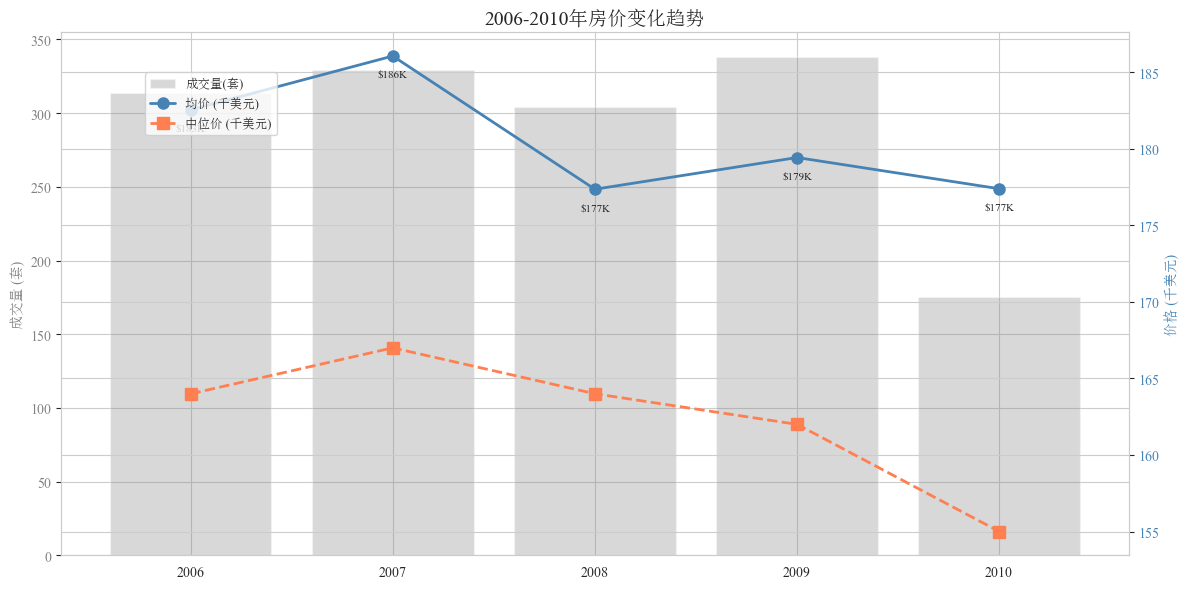

各年份统计:
            mean    median  count
YrSold                           
2006    182549.5  163995.0    314
2007    186063.2  167000.0    329
2008    177360.8  164000.0    304
2009    179432.1  162000.0    338
2010    177393.7  155000.0    175


In [25]:
# ============================================================
# 7.4 时间维度价格变化
# ============================================================
yearly = raw.groupby('YrSold')['SalePrice'].agg(['mean', 'median', 'count'])

fig, ax1 = plt.subplots(figsize=(12, 6))

# 柱状图: 成交量
ax1.bar(yearly.index, yearly['count'], alpha=0.3, color='gray', label='成交量(套)')
ax1.set_ylabel('成交量 (套)', color='gray')
ax1.tick_params(axis='y', labelcolor='gray')

# 折线图: 价格
ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly['mean']/1000, 'o-', color='steelblue',
         linewidth=2, markersize=8, label='均价 (千美元)')
ax2.plot(yearly.index, yearly['median']/1000, 's--', color='coral',
         linewidth=2, markersize=8, label='中位价 (千美元)')
ax2.set_ylabel('价格 (千美元)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

# 在点上标注数值
for yr in yearly.index:
    ax2.annotate(f'${yearly.loc[yr, "mean"]/1000:.0f}K',
                (yr, yearly.loc[yr, 'mean']/1000),
                textcoords="offset points", xytext=(0, -15), ha='center', fontsize=8)

plt.title('2006-2010年房价变化趋势', fontsize=14)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88), fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'price_over_time.png'), dpi=150, bbox_inches='tight')
plt.show()

print('各年份统计:')
print(yearly.round(1).to_string())

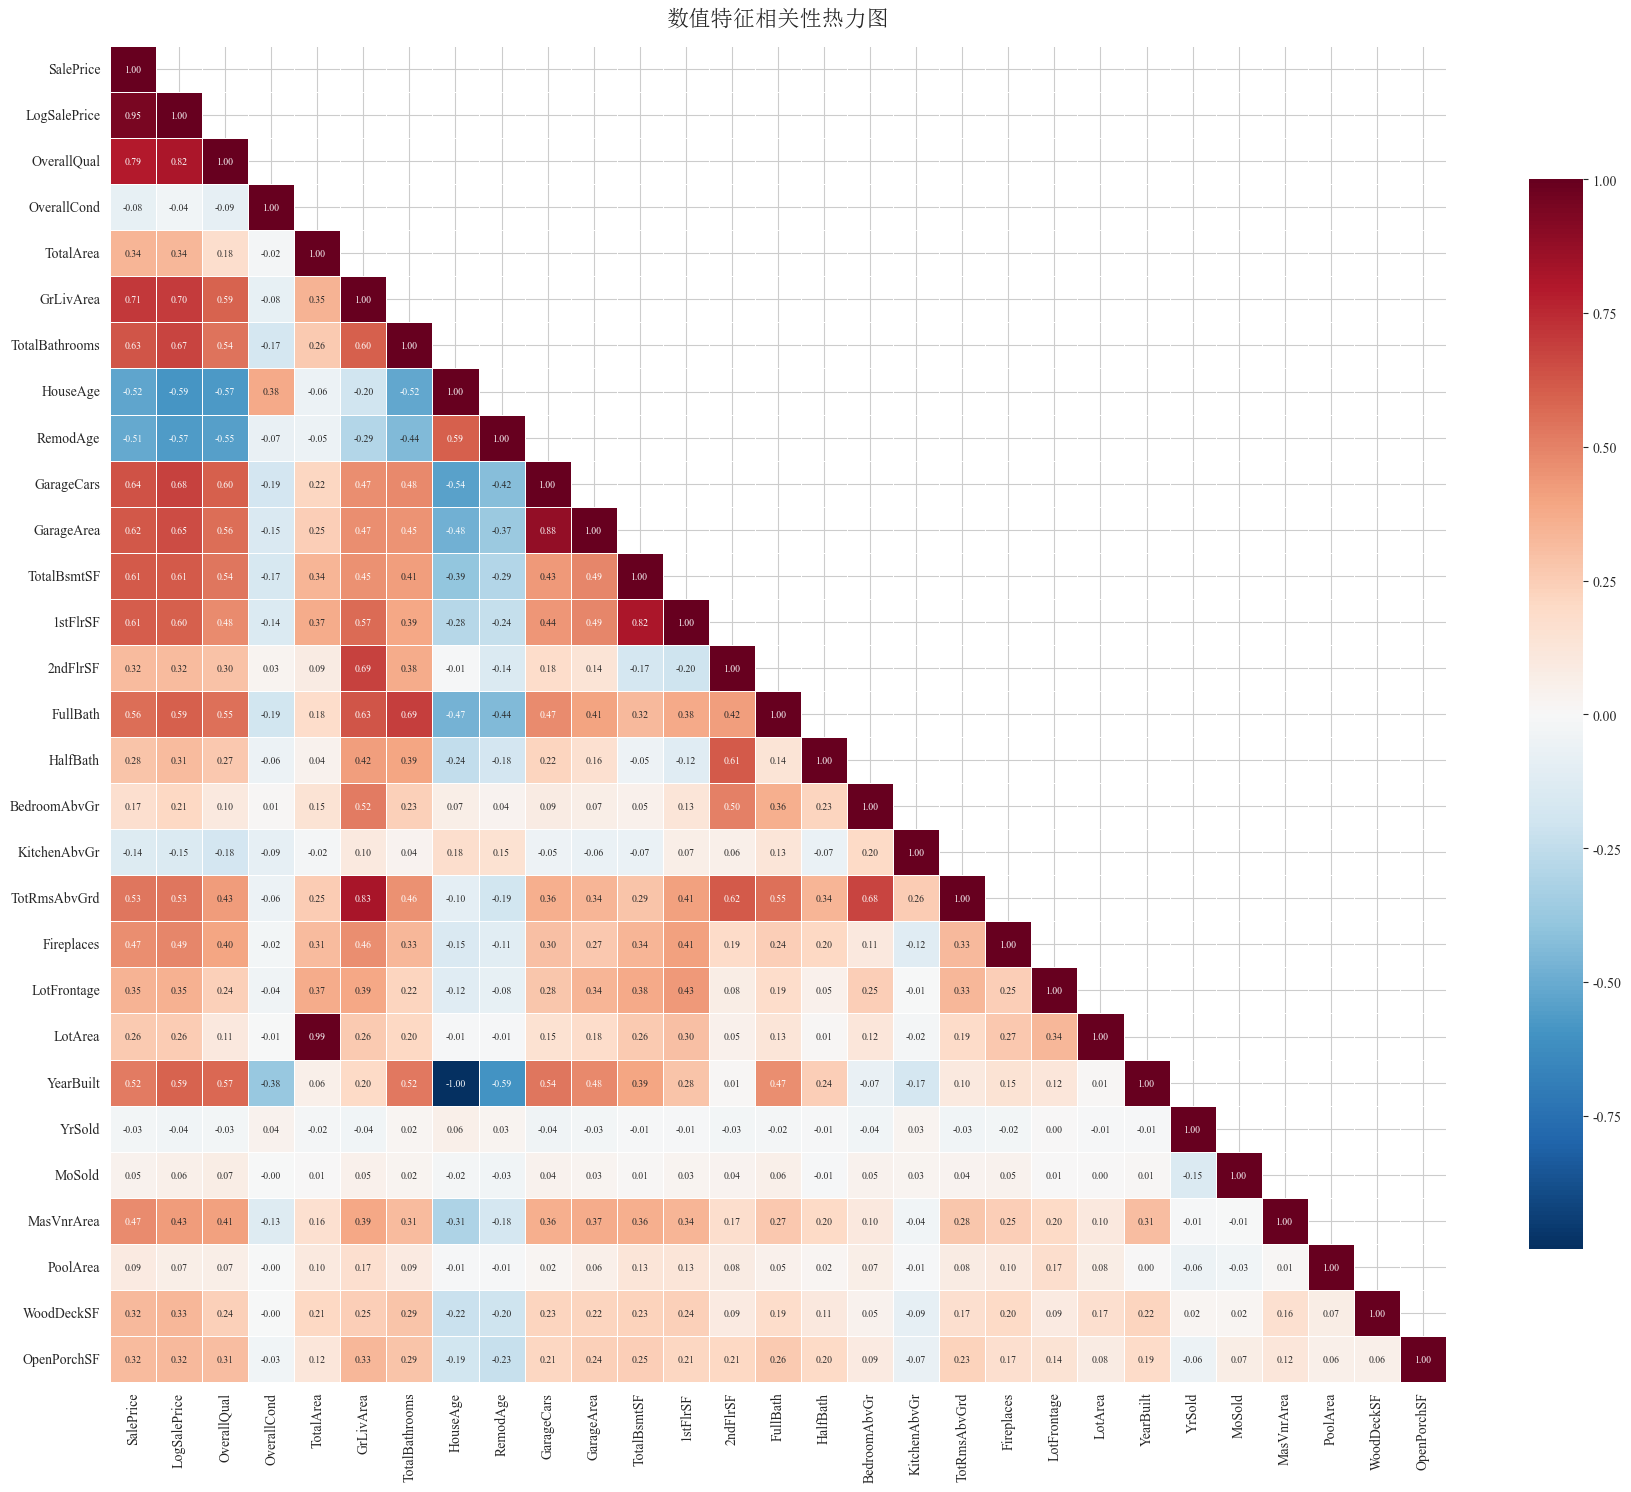

与 SalePrice 相关性最高的 10 个特征:
   1. LogSalePrice          r = +0.948  ████████████████████████████
   2. OverallQual           r = +0.791  ███████████████████████
   3. GrLivArea             r = +0.709  █████████████████████
   4. GarageCars            r = +0.640  ███████████████████
   5. TotalBathrooms        r = +0.632  ██████████████████
   6. GarageArea            r = +0.623  ██████████████████
   7. TotalBsmtSF           r = +0.614  ██████████████████
   8. 1stFlrSF              r = +0.606  ██████████████████
   9. FullBath              r = +0.561  ████████████████
  10. TotRmsAbvGrd          r = +0.534  ████████████████

与 SalePrice 相关性最低的 5 个特征:
   1. YrSold                r = -0.029
   2. OverallCond           r = -0.078
   3. KitchenAbvGr          r = -0.136
   4. RemodAge              r = -0.509
   5. HouseAge              r = -0.523


In [26]:
# ============================================================
# 7.5 特征相关性热力图
# ============================================================
corr_features = [
    'SalePrice', 'LogSalePrice', 'OverallQual', 'OverallCond',
    'TotalArea', 'GrLivArea', 'TotalBathrooms', 'HouseAge', 'RemodAge',
    'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
    'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
    'TotRmsAbvGrd', 'Fireplaces', 'LotFrontage', 'LotArea',
    'YearBuilt', 'YrSold', 'MoSold', 'MasVnrArea', 'PoolArea',
    'WoodDeckSF', 'OpenPorchSF',
]
# 过滤存在的列
corr_features = [c for c in corr_features if c in df.columns]

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(18, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.7},
            annot_kws={'fontsize': 7})
plt.title('数值特征相关性热力图', fontsize=16, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

# Top 10 与 SalePrice 最相关的特征
sale_corr = corr_matrix['SalePrice'].drop('SalePrice').sort_values(ascending=False)
print('与 SalePrice 相关性最高的 10 个特征:')
for i, (feat, corr_val) in enumerate(sale_corr.head(10).items(), 1):
    bar = '█' * max(1, int(abs(corr_val) * 30))
    print(f'  {i:>2d}. {feat:<20s}  r = {corr_val:+.3f}  {bar}')
print()
print('与 SalePrice 相关性最低的 5 个特征:')
for i, (feat, corr_val) in enumerate(sale_corr.tail(5).items(), 1):
    print(f'  {i:>2d}. {feat:<20s}  r = {corr_val:+.3f}')

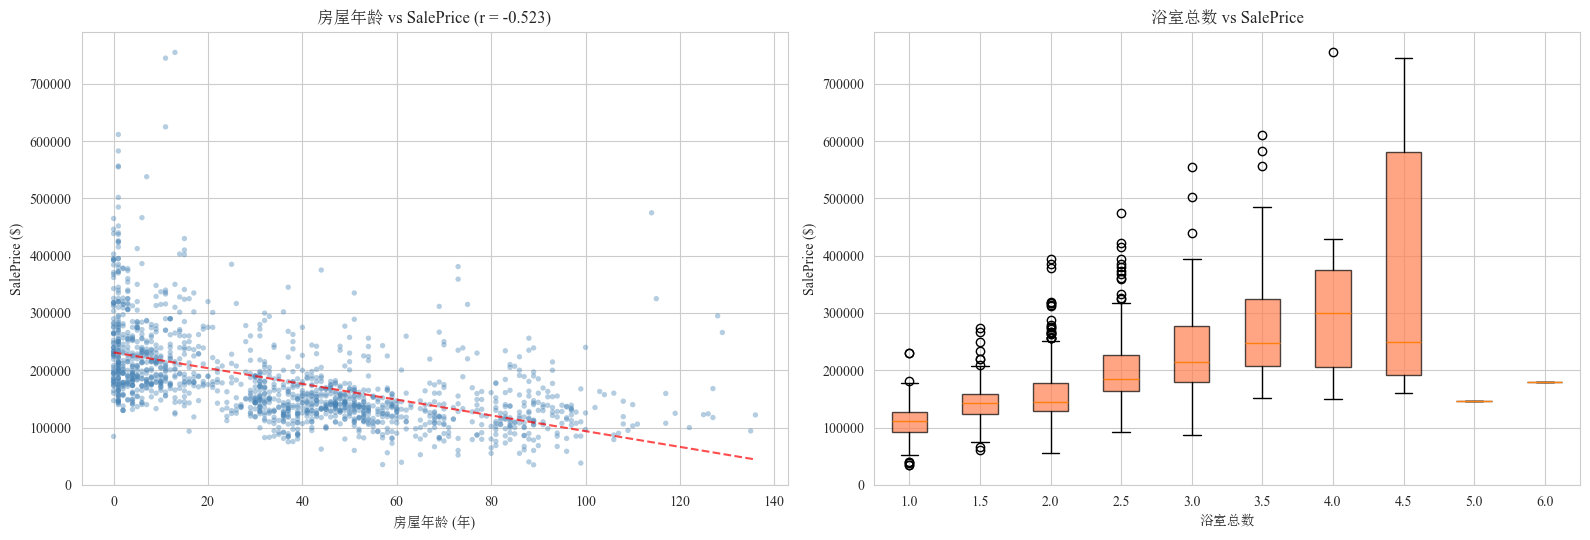

In [27]:
# ============================================================
# 7.6 附加分析：房龄与浴室数量 vs 价格
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# 房龄 vs 价格
axes[0].scatter(df['HouseAge'], df['SalePrice'], alpha=0.4, s=15,
                c='steelblue', edgecolors='none')
z = np.polyfit(df['HouseAge'], df['SalePrice'], 1)
p = np.poly1d(z)
axes[0].plot(sorted(df['HouseAge']), p(sorted(df['HouseAge'])),
             'r--', linewidth=1.5, alpha=0.7)
axes[0].set_title(f'房屋年龄 vs SalePrice (r = {df["HouseAge"].corr(df["SalePrice"]):.3f})',
                  fontsize=12)
axes[0].set_xlabel('房屋年龄 (年)')
axes[0].set_ylabel('SalePrice ($)')

# 总浴室数 vs 价格
bath_data = [df[df['TotalBathrooms'] == b]['SalePrice']
             for b in sorted(df['TotalBathrooms'].unique())]
bp = axes[1].boxplot(bath_data, patch_artist=True,
                     labels=[f'{b:.1f}' for b in sorted(df['TotalBathrooms'].unique())])
for patch in bp['boxes']:
    patch.set_facecolor('coral')
    patch.set_alpha(0.7)
axes[1].set_title('浴室总数 vs SalePrice', fontsize=12)
axes[1].set_xlabel('浴室总数')
axes[1].set_ylabel('SalePrice ($)')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'age_bathroom_price.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. EDA 关键发现总结

In [28]:
print('=' * 70)
print('                EDA 关键发现总结')
print('=' * 70)

print(f'''
【1. 房价分布】
   - SalePrice 呈右偏分布（偏度={df["SalePrice"].skew():.2f}），高价位房屋较少
   - 对数变换后分布接近正态（偏度={df["LogSalePrice"].skew():.2f}），适合线性回归建模
   - 房价范围: ${df["SalePrice"].min():,.0f} ~ ${df["SalePrice"].max():,.0f}
   - 均值 ${df["SalePrice"].mean():,.0f}，中位数 ${df["SalePrice"].median():,.0f}

【2. 面积与价格关系】
   - 地上居住面积(GrLivArea)与房价相关系数: {df["GrLivArea"].corr(df["SalePrice"]):.3f}
   - 房屋总面积(TotalArea)与房价相关系数: {df["TotalArea"].corr(df["SalePrice"]):.3f}
   - 整体质量评分(OverallQual)与房价呈现明显正阶梯关系
   - 存在少量面积大但价格偏低的异常样本

【3. 街区价格差异】
   - 不同街区房价差异显著，最贵街区均价可达最便宜街区的3-5倍
   - Neighborhood 是重要的分类预测特征（25个类别）

【4. 时间维度价格变化】
   - 2006-2010年间房价总体平稳，未见明显趋势性变化
   - 2008年金融危机在Ames地区影响相对有限

【5. 特征相关性】
   - 与SalePrice最强正相关: OverallQual、GrLivArea、GarageCars、TotalBsmtSF
   - HouseAge与价格呈负相关（新房更贵）
   - TotalBathrooms与价格正相关
''')

# 输出Top 5特征
sale_corr_final = df[corr_features].corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)
print('与 SalePrice 相关性最强的 Top 10 特征:')
for i, (feat, corr_val) in enumerate(sale_corr_final.head(10).items(), 1):
    print(f'  {i:>2d}. {feat:<20s}  |r| = {corr_val:.3f}')
print()
print('=' * 70)

                EDA 关键发现总结

【1. 房价分布】
   - SalePrice 呈右偏分布（偏度=1.88），高价位房屋较少
   - 对数变换后分布接近正态（偏度=0.12），适合线性回归建模
   - 房价范围: $34,900 ~ $755,000
   - 均值 $180,921，中位数 $163,000

【2. 面积与价格关系】
   - 地上居住面积(GrLivArea)与房价相关系数: 0.709
   - 房屋总面积(TotalArea)与房价相关系数: 0.343
   - 整体质量评分(OverallQual)与房价呈现明显正阶梯关系
   - 存在少量面积大但价格偏低的异常样本

【3. 街区价格差异】
   - 不同街区房价差异显著，最贵街区均价可达最便宜街区的3-5倍
   - Neighborhood 是重要的分类预测特征（25个类别）

【4. 时间维度价格变化】
   - 2006-2010年间房价总体平稳，未见明显趋势性变化
   - 2008年金融危机在Ames地区影响相对有限

【5. 特征相关性】
   - 与SalePrice最强正相关: OverallQual、GrLivArea、GarageCars、TotalBsmtSF
   - HouseAge与价格呈负相关（新房更贵）
   - TotalBathrooms与价格正相关

与 SalePrice 相关性最强的 Top 10 特征:
   1. LogSalePrice          |r| = 0.948
   2. OverallQual           |r| = 0.791
   3. GrLivArea             |r| = 0.709
   4. GarageCars            |r| = 0.640
   5. TotalBathrooms        |r| = 0.632
   6. GarageArea            |r| = 0.623
   7. TotalBsmtSF           |r| = 0.614
   8. 1stFlrSF              |r| = 0.606
   9. FullBath              |r| = 0.561

## 9. 数据交付说明

### 交付给成员C的文件

| 文件 | 路径 | 说明 |
|------|------|------|
| 训练集特征 | `data/processed/X_train.csv` | 1168行 × ~190列（编码后特征） |
| 测试集特征 | `data/processed/X_test.csv` | 292行 × ~190列 |
| 训练集目标 | `data/processed/y_train.csv` | 含 Id, SalePrice, LogSalePrice |
| 测试集目标 | `data/processed/y_test.csv` | 含 Id, SalePrice, LogSalePrice |
| 特征列名 | `data/processed/feature_columns.txt` | 所有特征列名列表 |
| EDA图表 | `figures/` | 8张PNG分析图表 |

### 处理步骤摘要

1. 区分并处理了结构性缺失（15列）与真实缺失（4列）
2. 创建了5个新特征：TotalArea, TotalBathrooms, HouseAge, RemodAge, AgeBand
3. 对19个有序变量进行了有序编码，22个名义变量进行了独热编码
4. 对 SalePrice 进行了对数变换（LogSalePrice）
5. 按 80%/20% 随机划分训练/测试集（random_state=42）

### 成员C使用说明

- 直接使用 `LogSalePrice` 作为目标变量进行模型训练
- 测试集评估时需将预测值从对数空间还原：`SalePrice = exp(prediction)`
- 独热编码保留了所有 dummy 列（drop_first=False），如需避免多重共线性可自行去掉每类首列
